# Primary Econometric Analysis (Full Notebook)

This notebook is the full, reproducible version of the econometric analysis, including figures and interpretation.

Research question:
- What is the effect of high AI occupational exposure on annual wage growth for white-collar professionals in Australia over 2020 to 2024, compared with low-AI occupations?

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
if project_root.name == 'output':
    project_root = project_root.parent

out = project_root / 'output'
coef_path = out / 'primary_econometric_key_coefficients.csv'
spec_path = out / 'primary_econometric_spec_check.csv'

coef = pd.read_csv(coef_path)
spec = pd.read_csv(spec_path)

coef.head()

,model,term,coef,se,pvalue
0,baseline_all,high_ai_exposure,-0.036281,0.007696,2.425755e-06
1,baseline_all,post_2021,-0.042100,0.004904,9.062118e-18
2,baseline_all,high_ai_x_post2021,0.016216,0.008173,4.723047e-02
3,baseline_all,occ_changed_anzsco2_1y,0.013721,0.006383,3.159141e-02
4,baseline_all,high_ai_x_post2021_x_mobility,0.011493,0.008395,1.709965e-01


## 1. Sample and setup\n
\n
- Estimation sample: 30,526 person-year observations, 9,354 people (complete-case sample).\n
- Outcome: `wage_growth_log_1y`.\n
- Key regressors: `high_ai_exposure`, `post_2021`, `high_ai_x_post2021`, `occ_changed_anzsco2_1y`, `high_ai_x_post2021_x_mobility`.\n
- Inference: clustered standard errors at person level.

In [3]:
baseline = coef[coef['model'] == 'baseline_all'].copy()
key_terms = [
    'high_ai_exposure',
    'high_ai_x_post2021',
    'occ_changed_anzsco2_1y',
    'high_ai_x_post2021_x_mobility',
]
labels = {
    'high_ai_exposure': 'High AI exposure',
    'high_ai_x_post2021': 'High AI x Post-2021',
    'occ_changed_anzsco2_1y': 'Occupation changed (1y)',
    'high_ai_x_post2021_x_mobility': 'High AI x Post-2021 x Mobility',
}

baseline = baseline[baseline['term'].isin(key_terms)].set_index('term').loc[key_terms].reset_index()
baseline['ci_low'] = baseline['coef'] - 1.96 * baseline['se']
baseline['ci_high'] = baseline['coef'] + 1.96 * baseline['se']

baseline[['term', 'coef', 'se', 'pvalue', 'ci_low', 'ci_high']]

,term,coef,se,pvalue,ci_low,ci_high
0,high_ai_exposure,-0.036281,0.007696,0.000002,-0.051365,-0.021197
1,high_ai_x_post2021,0.016216,0.008173,0.047230,0.000198,0.032235
2,occ_changed_anzsco2_1y,0.013721,0.006383,0.031591,0.001210,0.026232
3,high_ai_x_post2021_x_mobility,0.011493,0.008395,0.170996,-0.004962,0.027948


## 2. Baseline model figure\n
\n
The chart below shows baseline coefficients with 95% confidence intervals for core variables.

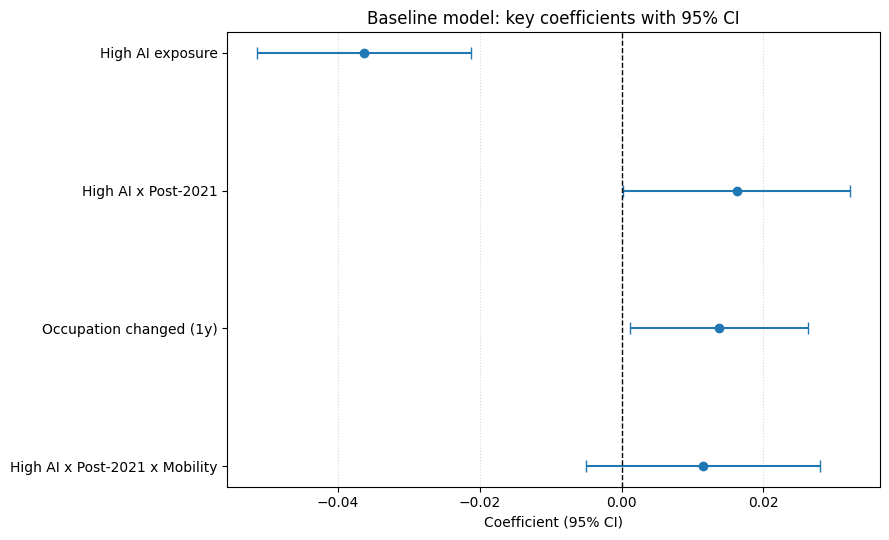

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
y = range(len(baseline))
ax.errorbar(
    baseline['coef'],
    y,
    xerr=[baseline['coef'] - baseline['ci_low'], baseline['ci_high'] - baseline['coef']],
    fmt='o',
    color='#1f77b4',
    ecolor='#1f77b4',
    capsize=4,
)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(list(y))
ax.set_yticklabels([labels[t] for t in baseline['term']])
ax.invert_yaxis()
ax.set_xlabel('Coefficient (95% CI)')
ax.set_title('Baseline model: key coefficients with 95% CI')
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Figure 1 interpretation

- `high_ai_exposure` is negative and statistically significant, meaning high-AI occupations have lower baseline wage growth before considering post-period interaction.
- `high_ai_x_post2021` is positive and borderline significant (`p=0.047`), suggesting a modest post-2021 differential for high-AI occupations.
- `occ_changed_anzsco2_1y` is positive and significant, indicating movers show higher wage-growth change on average.
- The triple interaction (`high_ai_x_post2021_x_mobility`) is positive but not statistically significant in this baseline specification.

## 3. Specification check figure (Spec A vs Spec B)\n
\n
- Spec A: include year fixed effects, drop `post_2021` main effect.\n
- Spec B: keep `post_2021` main effect, remove year fixed effects.\n
\n
This compares whether key coefficients are stable across valid alternatives.

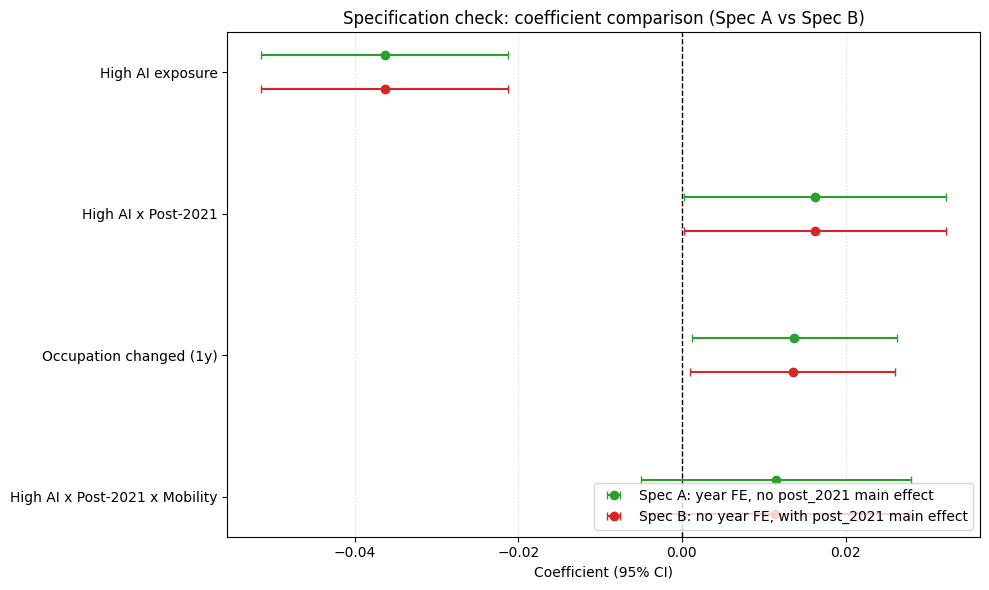

In [5]:
spec2 = spec[spec['term'].isin(key_terms)].copy()
spec2['ci_low'] = spec2['coef'] - 1.96 * spec2['se']
spec2['ci_high'] = spec2['coef'] + 1.96 * spec2['se']

model_order = ['specA_yearFE_noPostMain', 'specB_noYearFE_withPost']
model_labels = {
    'specA_yearFE_noPostMain': 'Spec A: year FE, no post_2021 main effect',
    'specB_noYearFE_withPost': 'Spec B: no year FE, with post_2021 main effect',
}
offsets = {'specA_yearFE_noPostMain': -0.12, 'specB_noYearFE_withPost': 0.12}
colors = {'specA_yearFE_noPostMain': '#2ca02c', 'specB_noYearFE_withPost': '#d62728'}
term_to_y = {t: i for i, t in enumerate(key_terms)}

fig, ax = plt.subplots(figsize=(10, 6))
for m in model_order:
    d = spec2[spec2['model'] == m].set_index('term').loc[key_terms].reset_index()
    yvals = [term_to_y[t] + offsets[m] for t in d['term']]
    ax.errorbar(
        d['coef'],
        yvals,
        xerr=[d['coef'] - d['ci_low'], d['ci_high'] - d['coef']],
        fmt='o',
        label=model_labels[m],
        color=colors[m],
        ecolor=colors[m],
        capsize=3,
    )

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(list(term_to_y.values()))
ax.set_yticklabels([labels[t] for t in key_terms])
ax.invert_yaxis()
ax.set_xlabel('Coefficient (95% CI)')
ax.set_title('Specification check: coefficient comparison (Spec A vs Spec B)')
ax.grid(axis='x', linestyle=':', alpha=0.5)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

### Figure 2 interpretation

- The coefficient for `high_ai_x_post2021` is very similar in both specs (around +0.016), which supports stability of the core interaction result.
- Other key coefficients also stay close across Spec A and Spec B.
- This reduces concern that the main conclusion is driven by one specific model setup.

## 4. Conclusion (plain-language summary)\n
\n
- The data and EDA are consistent with running this econometric setup.\n
- The average post-2021 differential for high-AI exposure is positive but modest.\n
- Mobility appears important, but the triple interaction is not statistically strong in the baseline model.\n
- This project is strongest as a heterogeneity and adjustment study, not a large average treatment-effect claim.

## Re-estimated regressions from panel data

This section re-runs the core regressions directly from the panel dataset, so the notebook includes both estimation and interpretation.

Models:
- Spec A: includes year fixed effects, excludes the post-2021 main effect.
- Spec B: excludes year fixed effects, includes the post-2021 main effect.

Standard errors:
- Clustered by person ID when an ID column is available.
- Otherwise HC1 robust standard errors are used.

In [6]:
import pandas as pd

try:
    import statsmodels.formula.api as smf
except ImportError as exc:
    raise ImportError("statsmodels is required for in-notebook regression estimation. Install it with: pip install statsmodels") from exc

panel_path = project_root / "data" / "clean" / "08_hilda_ai_analysis_panel.csv"
df_panel = pd.read_csv(panel_path)

print(f"Loaded panel data: {panel_path}")
print(f"Shape: {df_panel.shape[0]:,} rows x {df_panel.shape[1]} columns")
display(df_panel.head(3))

Loaded panel data: /Users/talia/Desktop/2026 S1/ECC3479/ecc3479-project/data/clean/08_hilda_ai_analysis_panel.csv
Shape: 35,185 rows x 21 columns


,xwaveid,wave,year,anzsco2,anzsco_major,is_white_collar,aioe2_mean,high_ai_exposure,post_2021,high_ai_x_post2021,...,pay_source,ln_pay,wage_growth_log_1y,occ_changed_anzsco2_1y,high_ai_x_post2021_x_mobility,hgsex,hgage,hhstate,jbocct,jbcmocc
0,1000014,t,2020,26,2,1,0.231455,1.0,0,0.0,...,crpay,0.000000,NaN,1.0,0.0,2.0,48.0,2.0,0.269231,1.0
1,1000020,t,2020,26,2,1,0.231455,1.0,0,0.0,...,jbmspay,2.302585,0.223144,0.0,0.0,2.0,34.0,8.0,14.000000,2.0
2,1000020,u,2021,13,1,1,0.264946,1.0,1,1.0,...,jbmspay,2.302585,0.000000,1.0,1.0,2.0,35.0,8.0,15.000000,1.0


In [8]:
def pick_col(df, candidates, required=False):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Required column not found. Tried: {candidates}")
    return None


def find_interaction_term(param_index, components):
    target = set(components)
    for name in param_index:
        if ":" not in name:
            continue
        parts = name.split(":")
        if len(parts) == len(components) and set(parts) == target:
            return name
    return None


y_col = pick_col(
    df_panel,
    [
        "wage_growth_log_1y",
        "annual_wage_growth",
        "wage_growth",
        "wage_growth_annual",
        "dlog_wage",
        "log_wage_growth",
    ],
    required=True,
)
ai_col = pick_col(df_panel, ["high_ai_exposure"], required=True)
post_col = pick_col(df_panel, ["post_2021", "post2021"])
mob_col = pick_col(df_panel, ["occ_changed_anzsco2_1y", "occ_changed_1y", "occupation_changed_1y"], required=True)
year_col = pick_col(df_panel, ["year", "survey_year", "wave_year"])
id_col = pick_col(df_panel, ["xwaveid", "person_id", "pid", "idperson"])

if post_col is None:
    if year_col is None:
        raise KeyError("Need either a post-2021 indicator or a year variable to construct one.")
    post_col = "post_2021"
    df_panel[post_col] = (df_panel[year_col] >= 2021).astype(int)

needed_cols = [c for c in [y_col, ai_col, post_col, mob_col, year_col, id_col] if c is not None]
df_reg = df_panel[needed_cols].dropna().copy()

formula_a = f"{y_col} ~ {ai_col} + {ai_col}:{post_col} + {mob_col} + {ai_col}:{post_col}:{mob_col}"
if year_col is not None:
    formula_a += f" + C({year_col})"

formula_b = f"{y_col} ~ {ai_col} + {post_col} + {ai_col}:{post_col} + {mob_col} + {ai_col}:{post_col}:{mob_col}"

use_cluster = id_col is not None and df_reg[id_col].nunique() > 30
if use_cluster:
    model_a = smf.ols(formula_a, data=df_reg).fit(cov_type="cluster", cov_kwds={"groups": df_reg[id_col]})
    model_b = smf.ols(formula_b, data=df_reg).fit(cov_type="cluster", cov_kwds={"groups": df_reg[id_col]})
    se_note = f"Clustered SE by {id_col}"
else:
    model_a = smf.ols(formula_a, data=df_reg).fit(cov_type="HC1")
    model_b = smf.ols(formula_b, data=df_reg).fit(cov_type="HC1")
    se_note = "HC1 robust SE"

print("Dependent variable:", y_col)
print("Sample size used:", f"{len(df_reg):,}")
print("SE type:", se_note)
print("Spec A formula:", formula_a)
print("Spec B formula:", formula_b)

Dependent variable: wage_growth_log_1y
Sample size used: 30,542
SE type: Clustered SE by xwaveid
Spec A formula: wage_growth_log_1y ~ high_ai_exposure + high_ai_exposure:post_2021 + occ_changed_anzsco2_1y + high_ai_exposure:post_2021:occ_changed_anzsco2_1y + C(year)
Spec B formula: wage_growth_log_1y ~ high_ai_exposure + post_2021 + high_ai_exposure:post_2021 + occ_changed_anzsco2_1y + high_ai_exposure:post_2021:occ_changed_anzsco2_1y


In [9]:
def summarize_key_terms(model, model_name, ai_col, post_col, mob_col):
    terms = {
        "High AI exposure": [ai_col],
        "High AI x Post-2021": [ai_col, post_col],
        "Occupation changed (1y)": [mob_col],
        "High AI x Post-2021 x Mobility": [ai_col, post_col, mob_col],
    }

    rows = []
    for label, comps in terms.items():
        if len(comps) == 1:
            term_name = comps[0] if comps[0] in model.params.index else None
        else:
            term_name = find_interaction_term(model.params.index, comps)

        if term_name is None:
            rows.append({
                "model": model_name,
                "term": label,
                "coef": float("nan"),
                "se": float("nan"),
                "pvalue": float("nan"),
                "ci_low": float("nan"),
                "ci_high": float("nan"),
            })
        else:
            rows.append({
                "model": model_name,
                "term": label,
                "coef": model.params[term_name],
                "se": model.bse[term_name],
                "pvalue": model.pvalues[term_name],
                "ci_low": model.conf_int().loc[term_name, 0],
                "ci_high": model.conf_int().loc[term_name, 1],
            })

    return pd.DataFrame(rows)

key_a = summarize_key_terms(model_a, "Spec A", ai_col, post_col, mob_col)
key_b = summarize_key_terms(model_b, "Spec B", ai_col, post_col, mob_col)
key_compare = pd.concat([key_a, key_b], ignore_index=True)

print("Spec A regression table (top rows):")
display(model_a.summary2().tables[1].head(12))
print("Spec B regression table (top rows):")
display(model_b.summary2().tables[1].head(12))

print("Key terms comparison:")
display(key_compare)

fit_stats = pd.DataFrame([
    {"model": "Spec A", "nobs": int(model_a.nobs), "r2": model_a.rsquared, "adj_r2": model_a.rsquared_adj},
    {"model": "Spec B", "nobs": int(model_b.nobs), "r2": model_b.rsquared, "adj_r2": model_b.rsquared_adj},
])
print("Model fit statistics:")
display(fit_stats)

Spec A regression table (top rows):


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,0.042694,0.006509,6.559206,5.409495e-11,0.029937,0.055451
C(year)[T.2021],-0.040642,0.008649,-4.699254,2.611137e-06,-0.057593,-0.023691
C(year)[T.2022],-0.071686,0.008057,-8.897394,5.717318e-19,-0.087478,-0.055895
C(year)[T.2023],-0.052398,0.007977,-6.569028,5.064493e-11,-0.068032,-0.036764
C(year)[T.2024],-0.047593,0.007915,-6.012734,1.824199e-09,-0.063106,-0.032079
high_ai_exposure,-0.010467,0.008477,-1.234762,2.169191e-01,-0.027081,0.006147
high_ai_exposure:post_2021,0.018864,0.009656,1.953489,5.076171e-02,-0.000063,0.037790
occ_changed_anzsco2_1y,0.020401,0.007153,2.851927,4.345514e-03,0.006381,0.034421
high_ai_exposure:post_2021:occ_changed_anzsco2_1y,0.007916,0.009857,0.803075,4.219315e-01,-0.011403,0.027235


Spec B regression table (top rows):


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,0.042765,0.006509,6.570238,5.023479e-11,0.030008,0.055523
high_ai_exposure,-0.010454,0.008476,-1.233301,2.174636e-01,-0.027066,0.006159
post_2021,-0.053020,0.007277,-7.285666,3.200855e-13,-0.067283,-0.038757
high_ai_exposure:post_2021,0.018846,0.009655,1.951905,5.094951e-02,-0.000078,0.037771
occ_changed_anzsco2_1y,0.019986,0.007159,2.791839,5.240935e-03,0.005955,0.034016
high_ai_exposure:post_2021:occ_changed_anzsco2_1y,0.007805,0.009863,0.791311,4.287626e-01,-0.011527,0.027137


Key terms comparison:


,model,term,coef,se,pvalue,ci_low,ci_high
0,Spec A,High AI exposure,-0.010467,0.008477,0.216919,-0.027081,0.006147
1,Spec A,High AI x Post-2021,0.018864,0.009656,0.050762,-0.000063,0.037790
2,Spec A,Occupation changed (1y),0.020401,0.007153,0.004346,0.006381,0.034421
3,Spec A,High AI x Post-2021 x Mobility,0.007916,0.009857,0.421932,-0.011403,0.027235
4,Spec B,High AI exposure,-0.010454,0.008476,0.217464,-0.027066,0.006159
5,Spec B,High AI x Post-2021,0.018846,0.009655,0.050950,-0.000078,0.037771
6,Spec B,Occupation changed (1y),0.019986,0.007159,0.005241,0.005955,0.034016
7,Spec B,High AI x Post-2021 x Mobility,0.007805,0.009863,0.428763,-0.011527,0.027137


Model fit statistics:


,model,nobs,r2,adj_r2
0,Spec A,30542,0.005227,0.004966
1,Spec B,30542,0.004150,0.003987


### Interpretation of the re-estimated models

- This section estimates the model directly from panel data, so coefficients and standard errors are generated in the notebook instead of being read from precomputed output files.
- Compare Spec A and Spec B by focusing on sign, magnitude, and confidence intervals for key interaction terms.
- If key terms remain directionally similar across the two specifications, that supports the robustness narrative in the main analysis.